Nicheformer implementation:  
We want to test the cabability of Nicheformer in capturing the spatial niche information


the tokenized parquet file should be run previously with the command as:  
python /scratch/project_465001027/Spatialformer/downstream/cell_cell_communication/benchmark/nicheformer/run_tokenize.py  

afterwards, there are batchs of parquet data generated in the ./data directory

In [1]:
import scanpy as sc
import anndata as ad
import numpy as np
import anndata as ad
from scipy.sparse import csr_matrix
import numba
import math
from tqdm import tqdm
from scipy.sparse import issparse
from sklearn.utils import sparsefuncs
import pyarrow.parquet as pq
import pyarrow
import os
import torch
import pandas as pd
import sys
sys.path.append("/scratch/project_465001027/nicheformer/src/nicheformer/models")
from _nicheformer import Nicheformer
from _fine_tune_model import FineTuningModel
from _utils import complete_masking
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score

In [2]:

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Building the input batch and dataloader

In [3]:
# Define the base directory
base_dir = "/scratch/project_465001027/Spatialformer/downstream/cell_cell_communication/benchmark/nicheformer/data"

# List all files in the directory
all_files = os.listdir(base_dir)

# Make sure to include the base directory in the file paths
full_paths = [os.path.join(base_dir, file) for file in all_files]

tables = []
# Print the full paths
for path in full_paths:
    tables.append(pd.read_parquet(path))
    
def generate_batches(tables, batch_size = 10, context_length=1500, cls_token = 2):
    for i, chunk in tqdm(enumerate(tables)):  # Process only the first table
        print(f"loading chunk {i}")
        for batch_num in range((len(chunk) + batch_size - 1) // batch_size):  # Correct range calculation for batches
            batch_df = chunk.iloc[batch_num * batch_size: (batch_num + 1) * batch_size]
            
            # Check if batch_df is empty
            if batch_df.empty:
                continue
            # Create the combined batch list
            batch_list = batch_df.apply(lambda x: list(x[["assay", "specie", "modality"]]) + list(x["X"]), axis=1)
            # Convert the batch_list into a tensor
            input_tensor = torch.tensor(batch_list.tolist(), dtype=torch.long)
            attention_mask = (input_tensor != 0)
            attention_mask = attention_mask.type(torch.bool)
            # Create the batch dictionary with input tensor
            batch = {'X': input_tensor[:,:context_length],"attention_mask":attention_mask,"assay":"xenium","specie":"human","modality":"spatial"}
            yield batch

# Loading the function

In [4]:
# Step 3: Load the pre-trained Nicheformer model
def load_nicheformer_model(checkpoint_path, config):
    model = Nicheformer(**config)
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['state_dict'])
    model.to(device)
    model.eval()
    return model

# Step 4: Extract embeddings using the model
def get_cell_embeddings(model, input_tensor_batches):
    embeddings_list = []
    with torch.no_grad():
        for batch in input_tensor_batches:
            batch["X"] = batch["X"].to(device)
            batch["attention_mask"] = batch["attention_mask"].to(device)
            output = model.get_embeddings(batch, layers=[11], function="mean")
            hidden_repr = output[0]
            embeddings_list.append(hidden_repr.cpu())

    if not embeddings_list:
        print("Error: No embeddings were generated.")
        return None
    all_embed = torch.cat(embeddings_list, dim=0)
    
    return all_embed.detach().numpy()

# Loading the model

In [5]:
# Model configuration
config = {
    'dim_model': 512,
    'nheads': 16,
    'dim_feedforward': 1024,
    'nlayers': 12,
    'dropout': 0.0,
    'batch_first': True,
    'masking_p': 0.15,
    'n_tokens': 20340,
    'context_length': 1500,
    'lr': 1e-4,
    'warmup': 1,
    'max_epochs': 50000,
    'pool': 'mean',
    'batch_size': 12,
    'autoregressive': False
}

checkpoint_path = '/scratch/project_465001027/Spatialformer/downstream/cell_cell_communication/benchmark/nicheformer/nicheformer.ckpt'

In [ ]:
model = load_nicheformer_model(checkpoint_path, config)

# Getting the embeddings for slides - 0008

In [8]:
input_tensor_batches = generate_batches(tables, batch_size = 8, context_length=1500, cls_token = 2)


In [ ]:
embs = get_cell_embeddings(model, input_tensor_batches)

In [10]:
embs.shape

(73785, 512)

save the nicheformer embeddings

In [11]:
import pickle
pickle.dump(embs, open("/scratch/project_465001027/Spatialformer/downstream/cell_cell_communication/benchmark/nicheformer/embeddings/THD0008_cell_embeddings_poollayers.pkl", "wb"))

In [2]:
import pickle
embs = pickle.load(open("/scratch/project_465001027/Spatialformer/downstream/cell_cell_communication/benchmark/nicheformer/embeddings/THD0008_cell_embeddings_poollayers.pkl", "rb"))

adding cell_ids as index for each of embedding

In [3]:
#index the embeddings by cell_ids
data_dir = "/scratch/project_465001027/spatialformer/david_data/relabel_output-XETG00048__0003392__THD0008__20230313__191400/outs/cell_feature_matrix"
adata = sc.read_10x_mtx(data_dir,  # The directory containing the files
                            var_names='gene_symbols',  # Use 'gene_ids' if you prefer the IDs
                            cache=True) 

adata

AnnData object with n_obs × n_vars = 73785 × 343
    var: 'gene_ids', 'feature_types'

# Getting the cell id

Getting the query cell id from the combined dataset

In [27]:
import pickle
from datasets import load_from_disk
sys.path.append("/scratch/project_465001027/Spatialformer/utils")
from utils import *
# all_left_indexs = pickle.load(open(f"/scratch/project_465001027/Spatialformer/data/all_left_indexs", "rb"))
# all_right_indexs = pickle.load(open(f"/scratch/project_465001027/Spatialformer/data/all_right_indexs", "rb"))
# all_preds = pickle.load(open("/scratch/project_465001027/Spatialformer/data/all_preds", "rb"))
all_left_indexs = pickle.load(open(f"/scratch/project_465001027/Spatialformer/data/all_left_indexs_20250108_204807_singleslide.pkl", "rb"))
all_right_indexs = pickle.load(open(f"/scratch/project_465001027/Spatialformer/data/all_right_indexs_20250108_204807_singleslide.pkl", "rb"))
all_preds = pickle.load(open("/scratch/project_465001027/Spatialformer/data/all_preds_20250108_204807_singleslide.pkl", "rb"))
 
#loading the 
combined_dataset = load_from_disk("/scratch/project_465001027/Spatialformer/cache/xenium_pandavid_dataset4")  
index_path = "/scratch/project_465001027/Spatialformer/data/sample_cell_index.pkl"
sample_cell_index = get_index(combined_dataset, save_file = index_path)
sample_name = "THD0008"
combined_dataset_all = concatenate_datasets([combined_dataset["train"], combined_dataset["test"], combined_dataset["validation"]])
sample_dataset = combined_dataset_all.select(list(sample_cell_index[sample_name].values()))

Loading dataset from disk:   0%|          | 0/364 [00:00<?, ?it/s]

Loading dataset from disk:   0%|          | 0/114 [00:00<?, ?it/s]

Loading dataset from disk:   0%|          | 0/91 [00:00<?, ?it/s]

In [28]:
sample_dataset

Dataset({
    features: ['Expression', 'Split', 'Cell_id', 'Gene', 'Cell_Ids', 'Ranked_Gene_Names', 'Full_Tokens', 'Gene_Gene_Matrix', 'Annotations', 'Sample_Names', 'Normalized_Exp', 'pct_nucleus', 'Transcript_Number', 'compound_key', 'Niche_Annotations', 'centroid_x', 'centroid_y'],
    num_rows: 57012
})

Getting the label, because we didn't save the label, which indicates the positive or negative pairs, we should retrive the original pair-wise matrix to get that

In [31]:
sparse_adj, cell_ids = get_adj(sample_dataset, radius = 30, plot = False, sym = True)

In [32]:
all_labels = {}
sparse_adj = sparse_adj.tocsr()
unique_query = np.unique(all_left_indexs)
max_keys_num = 0
for query in unique_query:
    query_index = np.where(all_left_indexs == query)[0]
    all_keys = all_right_indexs[query_index]
    if len(all_keys) > max_keys_num:
        max_keys_num = len(all_keys)
    indices_of_one = sparse_adj[[query], :].nonzero()[1]
    for key in all_keys:
        if key in indices_of_one:
            all_labels[(query, key)] = 1
        else:
            all_labels[(query, key)] = 0
#reorder the all_label as all_left_index
reorder_labels = {}
for query, key in zip(all_left_indexs, all_right_indexs):
    reorder_labels[(query, key)] = all_labels[(query, key)]
    

In [33]:
neg = 0
pos = 0
for query in unique_query[:1]:
    query_index = np.where(all_left_indexs == query)[0]
    all_keys = all_right_indexs[query_index]
    for key in all_keys:
        label = reorder_labels[(query, key)]
        print(f"({query}, {key}):", reorder_labels[(query, key)])
        if label == 0:
            neg += 1
        else:
            pos += 1

(213, 25635): 0
(213, 36551): 1
(213, 36573): 1
(213, 50622): 0
(213, 30349): 0
(213, 300): 1
(213, 29216): 0
(213, 37559): 1
(213, 24520): 0
(213, 36571): 1


Get the Nicheformer embeddings according to the cell ids

In [34]:
query_cell_ids = sample_dataset.select(all_left_indexs)["Cell_Ids"]
key_cell_ids = sample_dataset.select(all_right_indexs)["Cell_Ids"]

query_indexs = [list(adata.obs.index).index(cell_id) for cell_id in  query_cell_ids]
key_indexs = [list(adata.obs.index).index(cell_id) for cell_id in  key_cell_ids]

In [35]:
query_embs = embs[query_indexs]
key_embs = embs[key_indexs]

In [36]:
query_embs.shape

(17132, 512)

Getting the close cells

# Calculating the similarity

In [12]:
# Those functions are only used when faiss is not installed
def l2_sim(a, b):
    sims = -np.linalg.norm(a - b, axis=1)
    return sims

def get_similar_vectors(vector, ref, top_k=10):
    # sims = cos_sim(vector, ref)
    sims = l2_sim(vector, ref)

    top_k_idx = np.argsort(sims)[::-1][:top_k]
    return top_k_idx, sims[top_k_idx]

In [13]:
import numpy as np

def cosine_similarity(a, b):
    # Ensure both input arrays are numpy arrays
    a = np.array(a)
    b = np.array(b)
    
    # Compute dot product and norms
    dot_product = np.sum(a * b, axis=1)
    norm_a = np.linalg.norm(a, axis=1)
    norm_b = np.linalg.norm(b, axis=1)
    
    # Compute cosine similarity
    cosine_sim = dot_product / (norm_a * norm_b)
    
    return cosine_sim

# Example usage, with a as a 2D array where each row is a vector, and b is a single vector
a = np.array([[1, 2, 3], [4, 5, 6]])
b = np.array([[1, 0, 0], [0, 1, 0]])

similarity = cosine_similarity(a, b)
print("Cosine Similarity:", similarity)

Cosine Similarity: [0.26726124 0.56980288]


In [14]:
l2_sim(np.array([[1,2,3,4,5]]), np.array([[2,3,4,5,6]]))

array([-2.23606798])

Nicheformer performance

In [37]:
import faiss


overall_labels = []
overall_preds = []
nicheformer_pred = {}
index = faiss.IndexFlatL2(query_embs.shape[1])
index.add(key_embs)
for i, ori_query in tqdm(enumerate(np.unique(all_left_indexs))):
    #get querys and keys and labels
    
    
    ori_query_index = np.where(all_left_indexs == ori_query)[0]
    all_ori_keys = np.array(all_right_indexs)[ori_query_index]
    all_keys_num = len(all_ori_keys)
    all_labels = [reorder_labels[(ori_query, k)] for k in all_ori_keys]
#     index = faiss.IndexFlatL2(query_embs.shape[1])
#     index.add(key_embs[ori_query_index])
    
    query_vec = np.expand_dims(query_embs[ori_query_index[0]], axis=0)
    distances, close_indexs = index.search(query_vec, all_keys_num)
#     print(close_indexs[0], key_embs[ori_query_index].shape, query_vec.shape, distances)
    pred_results = [1 if index in close_indexs[0] else 0 for index in ori_query_index]
#     pred_results = np.zeros(all_keys_num)
#     all_ori_keys
#     print(all_keys_num, close_indexs.shape, int(all_keys_num/2), close_indexs[0], key_X[ori_query_index].shape)
#     pred_results[close_indexs[0][:int(all_keys_num/2)]] = 1 #get the first half as prediction
#     key_vecs = key_embs[ori_query_index]
#     similarity = np.array([cosine_similarity(query_vec, key_vecs[i:i+1,:]) for i,vec in enumerate(key_vecs)])
#     print(similarity)
#     pred_results = similarity > thredshold
#     print(all_labels, pred_results)
    overall_labels.extend(list(all_labels))
    overall_preds.extend(list(pred_results))
    for i,j in enumerate(pred_results):

        nicheformer_pred[(ori_query, all_ori_keys[i])] = j

# Calculate the confusion matrix
cm = confusion_matrix(overall_labels, overall_preds)

# Extract True Positives (TP), False Positives (FP), False Negatives (FN), and True Negatives (TN)
TP = cm[1, 1]  # True Positive
TN = cm[0, 0]  # True Negative
FP = cm[0, 1]  # False Positive
FN = cm[1, 0]  # False Negative

# Calculate metrics
accuracy = accuracy_score(overall_labels, overall_preds)
recall = recall_score(overall_labels, overall_preds)
precision = precision_score(overall_labels, overall_preds)
f1 = f1_score(overall_labels, overall_preds)

# Calculate Specificity (also known as True Negative Rate)
specificity = TN / (TN + FP) if (TN + FP) > 0 else 0  # Avoid division by zero
# Print metrics
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Accuracy: {accuracy:.4f}")   
print(f"F1 Score: {f1:.4f}")

500it [00:00, 545.15it/s]

Precision: 0.7500
Recall: 0.0060
Specificity: 0.9980
Accuracy: 0.5020
F1 Score: 0.0118


In [16]:
TP, TN, FP, FN

(31, 4213, 13, 4195)

In [38]:
reorder_nicheformer_pred = {}
for query, key in zip(all_left_indexs, all_right_indexs):
    reorder_nicheformer_pred[(query, key)] = nicheformer_pred[(query, key)]
    if nicheformer_pred[(query, key)] == 1:
        print((query, key))

(42545, 19324)
(47822, 36281)
(23924, 4471)
(35282, 35270)
(5737, 5597)
(47019, 31373)
(54857, 54887)
(35285, 43093)
(26095, 26093)
(33558, 56249)
(32640, 50545)
(39600, 9899)
(46513, 34654)
(37700, 48838)
(6105, 6112)
(51092, 40402)
(35009, 40210)
(35429, 41101)
(25995, 526)
(1403, 36984)
(32548, 46660)
(2712, 2666)
(46494, 32031)
(51925, 16128)
(37700, 3674)
(53066, 53065)
(47774, 36117)
(12122, 50969)
(37700, 37701)
(16331, 16202)
(49190, 24484)
(31823, 31827)
(13123, 40573)
(24026, 43981)
(31111, 31097)
(50930, 11981)
(46513, 32141)
(29933, 54919)
(42545, 42530)
(6440, 23660)
(51481, 14416)
(48811, 3452)
(1464, 37010)
(12260, 40327)
(11150, 51134)
(55719, 55736)
(1228, 36923)
(48854, 3827)
(10219, 10213)
(18772, 42414)
(43179, 19385)
(46454, 31827)
(54990, 13353)
(31823, 31883)
(6636, 38610)
(21639, 32777)
(26812, 7603)
(11923, 50929)
(52747, 56064)
(12180, 51009)
(1139, 2718)
(13567, 13559)
(49190, 4859)
(37734, 3774)
(463, 461)
(4650, 29319)
(39619, 9986)
(54502, 52113)


# Plot according to the JSD by selecting the top k_positive from nicheformer

In [39]:

def get_cell_comp(sparse_adj, sample_dataset, prob):
    cell_composition = {}
    sparse_adj = sparse_adj.tocsr() 
    Anns = sample_dataset["Annotations"]
    unique_types = sorted(Anns)  # Sort for consistent indexing
    nb_dict = {ct: 0 for ct in unique_types}  
    
    for cell_id in tqdm(range(sparse_adj.shape[0])):

        indices_of_one = sparse_adj[[cell_id], :].nonzero()[1]  # Get the column indices of the non-zero entries
        
        # Convert indices to a list of annotations
        if indices_of_one.size > 0:  # Check if any connected cells were found
            for indice in indices_of_one:
                nb_dict[Anns[indice]] += 1
            if prob:
                ct_num = np.sum(list(nb_dict.values()))
                for ct in nb_dict.keys():
                    nb_dict[ct] = nb_dict[ct]/ct_num
            
            cell_composition[cell_id] = nb_dict
            nb_dict = {ct: 0 for ct in unique_types}  


    return cell_composition

def get_pred_comp(sparse_adj, sample_dataset, left_indexs, right_indexs, preds, prob):
    Anns = sample_dataset["Annotations"]
    unique_types = sorted(np.unique(Anns))  # Sort for consistent indexing
    pred_cell_composition = {}
    
    # Using np.unique to get unique left indices
    unique_left_indexs = np.unique(left_indexs)
#     print("Unique left indices:", unique_left_indexs)
    
    for left_index in unique_left_indexs:
        nb_dict = {ct: 0 for ct in unique_types}  # Initialize counts for this left_index
        left_pos = np.where(left_indexs == left_index)[0]
#         print(left_pos)
        indices_of_one = right_indexs[left_pos]
        preds_of_one = preds[left_pos]
#         print(indices_of_one, preds_of_one)
        # Iterate through the indices and predictions
        for indice, pred in zip(indices_of_one, preds_of_one):
            if pred == 1:  # Only include the predicted indices to calculate the ratio
                nb_dict[Anns[indice]] += 1
        
        if prob:
            ct_num = np.sum(list(nb_dict.values()))
            # Normalize counts if ct_num is greater than zero
            if ct_num > 0:
                for ct in nb_dict.keys():
                    nb_dict[ct] /= ct_num
        
        pred_cell_composition[left_index] = nb_dict  # Store the result for this left_index

    return pred_cell_composition
        

In [40]:
sparse_adj, cell_ids = get_adj(sample_dataset, radius = 30, plot = False, sym = True)

In [41]:
sparse_adj

<57012x57012 sparse array of type '<class 'numpy.int64'>'
	with 976290 stored elements in COOrdinate format>

In [42]:
cell_composition = get_cell_comp(sparse_adj, sample_dataset, prob=False)

100%|██████████| 57012/57012 [01:44<00:00, 544.65it/s]


# Get the spatialformer prediction

In [46]:
import pickle
# all_left_indexs = pickle.load(open(f"/scratch/project_465001027/Spatialformer/data/all_left_indexs", "rb"))
# all_right_indexs = pickle.load(open(f"/scratch/project_465001027/Spatialformer/data/all_right_indexs", "rb"))
# all_preds = pickle.load(open("/scratch/project_465001027/Spatialformer/data/all_preds", "rb"))

all_left_indexs = pickle.load(open(f"/scratch/project_465001027/Spatialformer/data/all_left_indexs_20250108_213644_all61slides.pkl", "rb"))
all_right_indexs = pickle.load(open(f"/scratch/project_465001027/Spatialformer/data/all_right_indexs_20250108_213644_all61slides.pkl", "rb"))
all_preds = pickle.load(open("/scratch/project_465001027/Spatialformer/data/all_preds_20250108_213644_all61slides.pkl", "rb"))


In [47]:
all_labels = []
for left_index, right_index in zip(all_left_indexs, all_right_indexs):
    label = reorder_labels[(left_index, right_index)]
    all_labels.append(label)

In [50]:
# Calculate the confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Extract True Positives (TP), False Positives (FP), False Negatives (FN), and True Negatives (TN)
TP = cm[1, 1]  # True Positive
TN = cm[0, 0]  # True Negative
FP = cm[0, 1]  # False Positive
FN = cm[1, 0]  # False Negative

# Calculate metrics
accuracy = accuracy_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)

# Calculate Specificity (also known as True Negative Rate)
specificity = TN / (TN + FP) if (TN + FP) > 0 else 0  # Avoid division by zero
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Accuracy: {accuracy:.4f}")   
print(f"F1 Score: {f1:.4f}")

Precision: 0.6291
Recall: 0.8745
Specificity: 0.4845
Accuracy: 0.6795
F1 Score: 0.7318


In [51]:
all_labels

[0,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 0,


In [52]:
all_preds

array([1, 1, 1, ..., 1, 1, 1])

In [53]:
#only fetch the positive pairs
all_pos_left_index = []
all_pos_right_index = []
all_pos_pred = []
neg = []
pos = []
sparse_adj = sparse_adj.tocsr() 
for i,j,pred in zip(all_left_indexs, all_right_indexs, all_preds):
    value = sparse_adj[i,j]
    if value == 0:
        neg.append((i,j))
    else:
        all_pos_left_index.append(i)
        all_pos_right_index.append(j)
        pos.append((i,j))                                       
        all_pos_pred.append(pred)

all_pos_left_index = np.array(all_pos_left_index)
all_pos_right_index = np.array(all_pos_right_index)
all_pos_pred = np.array(all_pos_pred)
pred_cell_composition = get_pred_comp(sparse_adj, sample_dataset, all_pos_left_index, all_pos_right_index, all_pos_pred, prob = False)

In [54]:
all_preds

array([1, 1, 1, ..., 1, 1, 1])

In [55]:
len(all_pos_pred)

8566

In [56]:
np.sum(all_pos_pred)/len(all_pos_pred)

0.8745038524398786

In [57]:
all_pos_left_index[0]

44694

In [58]:
all_pos_right_index[0]

26297

# Get Nicheformer prediction

In [60]:
pos = []
neg = []
#only fetch the positive pairs
all_pos_left_index = []
all_pos_right_index = []
all_pos_pred = []
for i,j,pred in zip(all_left_indexs, all_right_indexs, reorder_nicheformer_pred.values()):
    value = sparse_adj[i,j]
    if value == 0:
        neg.append((i,j))
    else:
        all_pos_left_index.append(i)
        all_pos_right_index.append(j)
        pos.append((i,j))                                       
        all_pos_pred.append(pred)

all_pos_left_index = np.array(all_pos_left_index)
all_pos_right_index = np.array(all_pos_right_index)
all_pos_pred = np.array(all_pos_pred)
nf_pred_cell_composition = get_pred_comp(sparse_adj, sample_dataset, all_pos_left_index, all_pos_right_index, all_pos_pred, prob = False)

In [61]:
np.sum(all_pos_pred)/len(all_pos_pred)

0.005953770721456923

# Getting PCA prediction

Getting the PCA embeddings with the knn algorithm to tell pair or not paired

In [62]:
query_X.shape

NameError: name 'query_X' is not defined

In [63]:
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score

data_dir = "/scratch/project_465001027/spatialformer/david_data/relabel_output-XETG00048__0003392__THD0008__20230313__191400/outs/cell_feature_matrix"
adata = sc.read_10x_mtx(data_dir,  # The directory containing the files
                        var_names='gene_symbols',  # Use 'gene_ids' if you prefer the IDs
                        cache=True) 
#normalize the data
# sc.pp.normalize_total(adata, target_sum=1e4)
#run the pca to keep 40 priciple dimension
sc.tl.pca(adata, n_comps=50)  # Calculate 50 principal components
#selecting the expression vector of the query and key index

# Store the normalized PCA results back into the AnnData object, if desired
# adata.obsm['X_pca_normalized'] = pca_normalized
#for query index and key index
query_X = adata[query_indexs].obsm["X_pca"]
key_X = adata[key_indexs].obsm["X_pca"]
all_X = adata.obsm["X_pca"]

#getting the prediction metrics
overall_labels = []
overall_preds = []
pca_pred = {}
# thredshold = 0.5
index = faiss.IndexFlatL2(query_X.shape[1])
index.add(key_X)
#getting the top, all index here means adata index
for i, ori_query in tqdm(enumerate(np.unique(all_left_indexs))):
    
    ori_query_index = np.where(all_left_indexs == ori_query)[0] #return adata index
#     print(np.array(query_indexs)[query_index])
    adata_query = np.unique(np.array(query_indexs)[ori_query_index])[0]

    all_ori_keys = np.array(all_right_indexs)[ori_query_index]
    #applying the search -  this is validate when fassi is available
#     index = faiss.IndexFlatL2(query_X.shape[1])
#     index.add(key_X[ori_query_index])
    #getting the labels
    all_labels = np.array([reorder_labels[(ori_query, ori_k)] for ori_k in all_ori_keys])
    all_keys_num = len(all_ori_keys)#including positive and negative pairs
    
    
    
    # Query dataset, k - number of closest elements (returns 2 numpy arrays)
#     print(all_labels)
#     print(all_keys_num)
    query_vec = np.expand_dims(query_X[ori_query_index[0]], axis=0)
#     print(query_vec.shape)
    distances, close_indexs = index.search(query_vec, all_keys_num)
    pred_results = [1 if index in close_indexs[0] else 0 for index in ori_query_index]
#     key_vecs = key_X[ori_query_index]
#     similarity = np.array([cosine_similarity(query_vec, key_vecs[i:i+1,:]) for i,vec in enumerate(key_vecs)])
#     print(similarity)
#     pred_results = similarity > thredshold
#     print(pred_results)
#     print(distances)
#     pred_results = np.zeros(all_keys_num)
#     print(all_keys_num, close_indexs.shape, int(all_keys_num/2), close_indexs[0], key_X[ori_query_index].shape)
#     pred_results[close_indexs[0][:int(all_keys_num/2)]] = 1 #get the first half as prediction
#     print(all_labels, pred_results)
    overall_labels.extend(list(all_labels))
    overall_preds.extend(list(pred_results))
    for i,j in enumerate(pred_results):

        pca_pred[(ori_query, all_ori_keys[i])] = j

# Calculate the confusion matrix
cm = confusion_matrix(overall_labels, overall_preds)

# Extract True Positives (TP), False Positives (FP), False Negatives (FN), and True Negatives (TN)
TP = cm[1, 1]  # True Positive
TN = cm[0, 0]  # True Negative
FP = cm[0, 1]  # False Positive
FN = cm[1, 0]  # False Negative

# Calculate metrics
accuracy = accuracy_score(overall_labels, overall_preds)
recall = recall_score(overall_labels, overall_preds)
precision = precision_score(overall_labels, overall_preds)
f1 = f1_score(overall_labels, overall_preds)

# Calculate Specificity (also known as True Negative Rate)
specificity = TN / (TN + FP) if (TN + FP) > 0 else 0  # Avoid division by zero
# Print metrics
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Accuracy: {accuracy:.4f}")   
print(f"F1 Score: {f1:.4f}")

500it [00:00, 606.72it/s]

Precision: 0.9266
Recall: 0.0236
Specificity: 0.9981
Accuracy: 0.5109
F1 Score: 0.0460


In [64]:
reorder_pca_pred = {}
for query, key in zip(all_left_indexs, all_right_indexs):
    reorder_pca_pred[(query, key)] = pca_pred[(query, key)]
    if pca_pred[(query, key)] == 1:
        print((query, key))

(2400, 2398)
(35285, 35298)
(16636, 52055)
(25466, 44439)
(46494, 32027)
(42559, 42521)
(16649, 16648)
(42707, 5249)
(8176, 8075)
(23924, 23930)
(47422, 34909)
(18694, 18680)
(28797, 45478)
(56385, 35114)
(6440, 6498)
(35282, 35271)
(5350, 5321)
(16649, 52039)
(7657, 7659)
(9190, 39372)
(48811, 37631)
(29752, 29747)
(46454, 31888)
(22235, 43444)
(9206, 9201)
(49850, 7543)
(51855, 41482)
(42545, 19203)
(42545, 52674)
(19526, 19480)
(6814, 38664)
(54558, 25431)
(27963, 54875)
(1857, 1853)
(42545, 42540)
(12201, 12191)
(19526, 19527)
(25965, 25848)
(6636, 38618)
(42122, 17853)
(9677, 7371)
(33558, 33521)
(48729, 43069)
(50126, 8703)
(5350, 49310)
(20769, 43029)
(55805, 31501)
(20769, 20783)
(52141, 16919)
(43179, 21525)
(34213, 34150)
(37082, 1711)
(26693, 26698)
(17909, 52375)
(48811, 37636)
(24904, 25006)
(5350, 5316)
(30238, 30236)
(698, 707)
(42559, 19293)
(18772, 52567)
(43179, 21546)
(43179, 53253)
(21639, 43202)
(41632, 16215)
(43179, 21535)
(4173, 4207)
(23826, 53824)
(43179, 5321

# Predict PCA results

In [65]:
pos = []
neg = []
#only fetch the positive pairs
all_pos_left_index = []
all_pos_right_index = []
all_pos_pred = []
sparse_adj = sparse_adj.tocsr() 
for i,j,pred in zip(all_left_indexs, all_right_indexs, reorder_pca_pred.values()):
    value = sparse_adj[i,j]
    if value == 0:
        neg.append((i,j))
    else:
        all_pos_left_index.append(i)
        all_pos_right_index.append(j)
        pos.append((i,j))                                       
        all_pos_pred.append(pred)

all_pos_left_index = np.array(all_pos_left_index)
all_pos_right_index = np.array(all_pos_right_index)
all_pos_pred = np.array(all_pos_pred)
pca_pred_cell_composition = get_pred_comp(sparse_adj, sample_dataset, all_pos_left_index, all_pos_right_index, all_pos_pred, prob = False)

# Getting CellContrast prediction

In [66]:
import sys
sys.path.append("/scratch/project_465001027/Spatialformer/downstream/cell_cell_communication/benchmark/CellContrast/")
from cellContrast.model import *
from cellContrast import utils
import json
from scipy import sparse

def load_model(ckp_path, param_path):
    
    save_folder = ckp_path
    if(dev=="cpu"):
        checkpoint = torch.load(save_folder,map_location="cpu")
    else:
        checkpoint = torch.load(save_folder)
    
    model_state_dict = checkpoint['model_state_dict']
    train_genes = checkpoint["train_genes"]
    
    # load parameter settings
    with open(param_path,"r") as json_file:
        params = json.load(json_file)
    params["n_input"] = len(train_genes)
   
    # init the model
    model = CellContrastModel(n_input=params['n_input'],\
                              n_encoder_hidden=params["n_encoder_hidden"],n_encoder_latent=params["n_encoder_latent"],\
                              n_encoder_layers=params["n_encoder_layers"],n_projection_hidden=params["n_projection_hidden"],\
                              n_projection_output=params["n_projection_output"])
    
    # load model states
    model.load_state_dict(model_state_dict)    
    return model,train_genes

def infer_representations(model,query_adata):
    
    print("device",device)
    if(sparse.issparse(query_adata.X)):
        input_gene_exp = np.asarray(query_adata.X.todense())
    else:
        input_gene_exp = query_adata.X
        
    torch.tensor(input_gene_exp).float().to(device)
    model.eval()
    print("running the prediction/inference")
    representation, projection = model(torch.tensor(input_gene_exp).float().to(device))
    if(dev!="cpu"):
        representation = representation.cpu()
        
    return representation.detach().numpy()

if torch.cuda.is_available():
    dev = "cuda"
else:
    dev = "cpu"
device = torch.device(dev)
# load params
with open("/scratch/project_465001027/Spatialformer/downstream/cell_cell_communication/benchmark/CellContrast/parameters/parameters_singleCell.json","r") as json_file:
    params = json.load(json_file)
    
# load models
param_path = "/scratch/project_465001027/Spatialformer/downstream/cell_cell_communication/benchmark/CellContrast/parameters/parameters_singleCell.json"
ckp_path = "/scratch/project_465001027/Spatialformer/downstream/cell_cell_communication/benchmark/CellContrast/cellContrast_models/epoch_3000.pt"
model, train_genes = load_model(ckp_path,param_path)
model.to(device)
print("model",model)

#getting embeddings
representation = infer_representations(model,adata)


model CellContrastModel(
  (encoder): Encoder(
    (hidden_layers): ModuleList(
      (0): Linear(in_features=343, out_features=1024, bias=True)
      (1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.01)
      (3): Dropout(p=0, inplace=False)
    )
    (output_layer): Linear(in_features=1024, out_features=512, bias=True)
    (bn_layer): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (dropout_layer): Dropout(p=0, inplace=False)
    (activation_layer): LeakyReLU(negative_slope=0.01)
  )
  (projection): ProjectionHead(
    (fc1): Linear(in_features=512, out_features=256, bias=True)
    (relu): ReLU(inplace=True)
    (fc2): Linear(in_features=256, out_features=128, bias=True)
  )
)
device cuda
running the prediction/inference


getting the cellcontrast embeddings

In [67]:
celltst_query_embs = representation[query_indexs]
celltst_key_embs = representation[key_indexs]

getting the performance

In [68]:
import faiss


overall_labels = []
overall_preds = []
cellcontrast_pred = {}
index = faiss.IndexFlatL2(celltst_query_embs.shape[1])
index.add(celltst_key_embs)
for i, ori_query in tqdm(enumerate(np.unique(all_left_indexs))):
    #get querys and keys and labels
    
    
    ori_query_index = np.where(all_left_indexs == ori_query)[0]
    all_ori_keys = np.array(all_right_indexs)[ori_query_index]
    all_keys_num = len(all_ori_keys)
    all_labels = [reorder_labels[(ori_query, k)] for k in all_ori_keys]
#     index = faiss.IndexFlatL2(query_embs.shape[1])
#     index.add(key_embs[ori_query_index])
    
    query_vec = np.expand_dims(celltst_query_embs[ori_query_index[0]], axis=0)
    distances, close_indexs = index.search(query_vec, all_keys_num)
#     print(close_indexs[0], key_embs[ori_query_index].shape, query_vec.shape, distances)
    pred_results = [1 if index in close_indexs[0] else 0 for index in ori_query_index]

    overall_labels.extend(list(all_labels))
    overall_preds.extend(list(pred_results))
    for i,j in enumerate(pred_results):

        cellcontrast_pred[(ori_query, all_ori_keys[i])] = j

# Calculate the confusion matrix
cm = confusion_matrix(overall_labels, overall_preds)

# Extract True Positives (TP), False Positives (FP), False Negatives (FN), and True Negatives (TN)
TP = cm[1, 1]  # True Positive
TN = cm[0, 0]  # True Negative
FP = cm[0, 1]  # False Positive
FN = cm[1, 0]  # False Negative

# Calculate metrics
accuracy = accuracy_score(overall_labels, overall_preds)
recall = recall_score(overall_labels, overall_preds)
precision = precision_score(overall_labels, overall_preds)
f1 = f1_score(overall_labels, overall_preds)

# Calculate Specificity (also known as True Negative Rate)
specificity = TN / (TN + FP) if (TN + FP) > 0 else 0  # Avoid division by zero
# Print metrics
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Accuracy: {accuracy:.4f}")   
print(f"F1 Score: {f1:.4f}")

500it [00:00, 541.62it/s]

Precision: 0.9186
Recall: 0.0237
Specificity: 0.9979
Accuracy: 0.5108
F1 Score: 0.0462


In [69]:
reorder_cc_pred = {}
for query, key in zip(all_left_indexs, all_right_indexs):
    reorder_cc_pred[(query, key)] = cellcontrast_pred[(query, key)]
    if cellcontrast_pred[(query, key)] == 1:
        print((query, key))

(2400, 2398)
(53492, 22392)
(35285, 35298)
(16636, 52055)
(25466, 44439)
(38189, 49308)
(7657, 7651)
(42559, 42521)
(18694, 18680)
(46730, 33022)
(39098, 39100)
(56385, 35114)
(30744, 30704)
(35282, 35271)
(14028, 4417)
(17909, 18128)
(50930, 11984)
(55840, 31821)
(47945, 36545)
(38189, 5222)
(37082, 1738)
(37082, 37981)
(29752, 29747)
(6814, 6823)
(9206, 9201)
(1006, 48167)
(29752, 29737)
(42545, 19203)
(42545, 52674)
(19526, 19480)
(6814, 38664)
(42545, 42540)
(42707, 52804)
(5737, 5597)
(54513, 44776)
(18989, 21162)
(21639, 21525)
(42122, 17853)
(10287, 10294)
(42559, 19294)
(10261, 10260)
(50394, 9849)
(13980, 13978)
(26693, 26712)
(45112, 27656)
(5350, 49310)
(2248, 48457)
(52382, 18144)
(42559, 19194)
(44979, 27219)
(20769, 20752)
(20769, 20783)
(13567, 37561)
(38852, 7476)
(14028, 40837)
(37082, 1711)
(26693, 26698)
(9017, 50215)
(18772, 18774)
(24904, 25006)
(30238, 30236)
(20769, 20759)
(42559, 19293)
(29096, 29092)
(21639, 43202)
(37082, 1708)
(41632, 16215)
(39619, 10110)
(5

Get composition results

In [70]:
pos = []
neg = []
#only fetch the positive pairs
all_pos_left_index = []
all_pos_right_index = []
all_pos_pred = []
sparse_adj = sparse_adj.tocsr() 
for i,j,pred in zip(all_left_indexs, all_right_indexs, reorder_cc_pred.values()):
    value = sparse_adj[i,j]
    if value == 0:
        neg.append((i,j))
    else:
        all_pos_left_index.append(i)
        all_pos_right_index.append(j)
        pos.append((i,j))                                       
        all_pos_pred.append(pred)

all_pos_left_index = np.array(all_pos_left_index)
all_pos_right_index = np.array(all_pos_right_index)
all_pos_pred = np.array(all_pos_pred)
cc_pred_cell_composition = get_pred_comp(sparse_adj, sample_dataset, all_pos_left_index, all_pos_right_index, all_pos_pred, prob = False)

# Get overall composition

In [71]:
unique_left_indexs = np.unique(all_pos_left_index)
Anns = sample_dataset["Annotations"]
unique_types = sorted(np.unique(Anns)) # Sort for consistent indexing
tp = 0
total_t = 0
ct_tp = {}
nf_ct_tp = {}
pca_ct_tp = {}
cc_ct_tp = {}
ct_total = {}
recall_ct = {}
for query in unique_left_indexs:
    gt_ct_dict = cell_composition[query]
    pred_ct_dict = pred_cell_composition[query]
    nf_ct_dict = nf_pred_cell_composition[query]
    pca_ct_dict = pca_pred_cell_composition[query]
    cc_ct_dict = cc_pred_cell_composition[query]
    for ct, gt_ct_num in gt_ct_dict.items():
        pred_ct_num = pred_ct_dict[ct]
        nf_pred_ct_num = nf_ct_dict[ct]
        pca_pred_ct_num = pca_ct_dict[ct]
        cc_pred_ct_num = cc_ct_dict[ct]
        ct_total.setdefault(ct, []).append(gt_ct_num)
        ct_tp.setdefault(ct, []).append(pred_ct_num)
        nf_ct_tp.setdefault(ct, []).append(nf_pred_ct_num)
        pca_ct_tp.setdefault(ct, []).append(pca_pred_ct_num)
        cc_ct_tp.setdefault(ct, []).append(cc_pred_ct_num)
# ratio_dict = {}
# for ct in unique_types:
#     supports = np.sum(ct_total[ct])
#     ratio_dict[f"{ct}_({supports})"] = np.sum(ct_tp[ct])/np.sum(ct_total[ct])
     

In [72]:
import numpy as np

def kl_divergence(p, q):
    """Compute the KL divergence D(p || q)."""
    # Avoid division by zero by using a small epsilon value in q
    epsilon = 1e-10
    q = np.where(q == 0, epsilon, q)  # Replace 0 in q with a small epsilon
    return np.sum(np.where(p != 0, p * np.log(p / q), 0))

def jsd(p, q):
    """Compute the Jensen-Shannon Divergence between two probability distributions."""
    # Normalize p and q to ensure they are valid distributions
    p = p / np.sum(p) if np.sum(p) > 0 else 0 
    q = q / np.sum(q) if np.sum(q) > 0 else 0
    
    # Compute M
    m = 0.5 * (p + q)
    
    # Compute JSD
    return 0.5 * kl_divergence(p, m) + 0.5 * kl_divergence(q, m)

def count_JSD(P_counts, Q_counts):
    
    # Compute probability distributions
    P = P_counts / np.sum(P_counts) if np.sum(P_counts) > 0 else 0
    Q = Q_counts / np.sum(Q_counts) if np.sum(Q_counts) > 0 else 0
    # Compute JSD
    jsd_score = jsd(P, Q)
    print("Jensen-Shannon Divergence (JSD) score:", jsd_score)
    return jsd_score

In [73]:
#Calculating JSD for each cell type
ct_jsd = {}
nf_ct_jsd = {}
pca_ct_jsd = {}
cc_ct_jsd = {}
for ct,gt_dis in ct_total.items():
    pred_dis = ct_tp[ct]
    
    
    nf_pred_dis = nf_ct_tp[ct]
    pca_pred_dis = pca_ct_tp[ct]
    cc_pred_dis = cc_ct_tp[ct]
    jsd_score = count_JSD(pred_dis, gt_dis)
    nf_jsd_score = count_JSD(nf_pred_dis, gt_dis)
    pca_jsd_score = count_JSD(pca_pred_dis, gt_dis)
    cc_jsd_score = count_JSD(cc_pred_dis, gt_dis)
    ct_jsd[ct] = jsd_score
    nf_ct_jsd[ct] = nf_jsd_score
    pca_ct_jsd[ct] = pca_jsd_score
    cc_ct_jsd[ct] = cc_jsd_score

Jensen-Shannon Divergence (JSD) score: 0.06435350528406279
Jensen-Shannon Divergence (JSD) score: 0.6206006385321683
Jensen-Shannon Divergence (JSD) score: 0.6578443585305771
Jensen-Shannon Divergence (JSD) score: 0.3465735902799726
Jensen-Shannon Divergence (JSD) score: 0.02886133652190689
Jensen-Shannon Divergence (JSD) score: 0.669674924118544
Jensen-Shannon Divergence (JSD) score: 0.5665909972301102
Jensen-Shannon Divergence (JSD) score: 0.5518342616650936
Jensen-Shannon Divergence (JSD) score: 0.34657359027997264
Jensen-Shannon Divergence (JSD) score: 0.34657359027997264
Jensen-Shannon Divergence (JSD) score: 0.34657359027997264
Jensen-Shannon Divergence (JSD) score: 0.34657359027997264
Jensen-Shannon Divergence (JSD) score: 0.07851217417151508
Jensen-Shannon Divergence (JSD) score: 0.608374893222875
Jensen-Shannon Divergence (JSD) score: 0.48298256351213803
Jensen-Shannon Divergence (JSD) score: 0.5794669828984903
Jensen-Shannon Divergence (JSD) score: 0.02314677615584846
Jensen-

/tmp/ipykernel_32634/2175646944.py:8: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.where(p != 0, p * np.log(p / q), 0))
/tmp/ipykernel_32634/2175646944.py:8: RuntimeWarning: invalid value encountered in multiply
  return np.sum(np.where(p != 0, p * np.log(p / q), 0))
/tmp/ipykernel_32634/2175646944.py:8: RuntimeWarning: invalid value encountered in double_scalars
  return np.sum(np.where(p != 0, p * np.log(p / q), 0))


In [74]:
df_sf = pd.DataFrame(list(ct_jsd.items()), columns=['Cell Type', 'JSD'])

In [75]:
df_nf = pd.DataFrame(list(nf_ct_jsd.items()), columns=['Cell Type', 'JSD'])

In [76]:
df_pca = pd.DataFrame(list(pca_ct_jsd.items()), columns=['Cell Type', 'JSD'])

In [77]:
df_cc = pd.DataFrame(list(cc_ct_jsd.items()), columns=['Cell Type', 'JSD'])

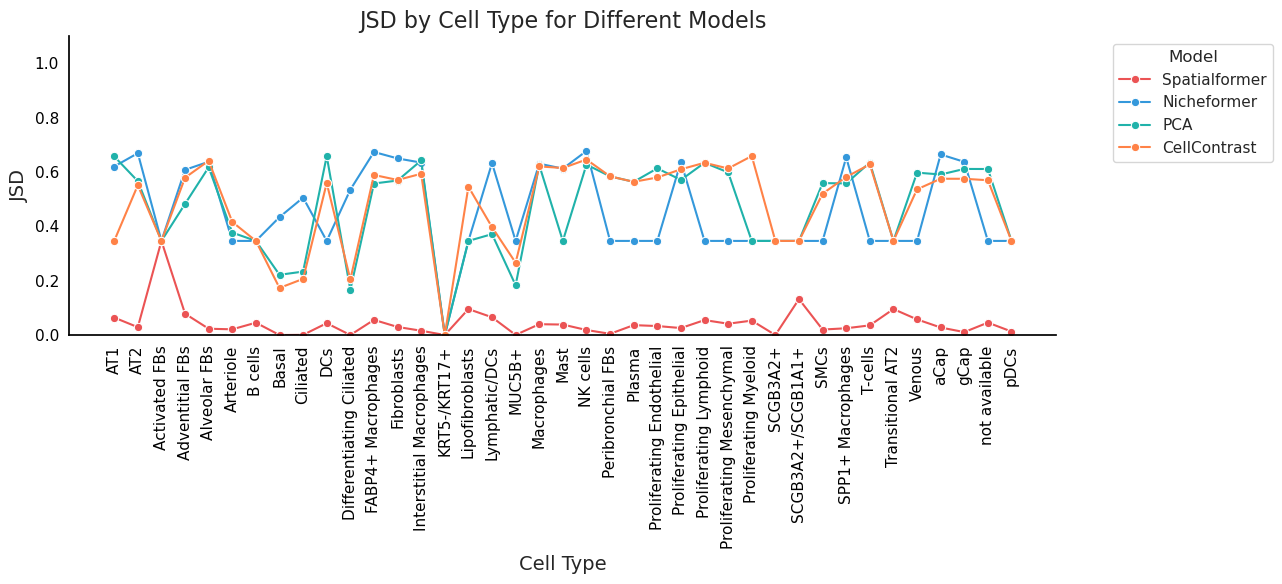

In [78]:
import seaborn as sns
# Assuming sf_jsd and nf_jsd are your dictionaries
df_sf = pd.DataFrame(list(ct_jsd.items()), columns=['Cell Type', 'JSD'])
df_nf = pd.DataFrame(list(nf_ct_jsd.items()), columns=['Cell Type', 'JSD'])

# Add a column to identify the source of the data
df_sf['Model'] = 'Spatialformer'
df_nf['Model'] = 'Nicheformer'
df_pca['Model'] = "PCA"
df_cc['Model'] = "CellContrast"

# Combine the two DataFrames
combined_df = pd.concat([df_sf, df_nf, df_pca, df_cc], ignore_index=True)

# Drop NaN values if necessary
combined_df.dropna(inplace=True)

# Set the aesthetics with seaborn
sns.set(style='whitegrid')
# Create a custom color palette
palette = {
    'Spatialformer': '#EB5354',  # Choose your color
    'Nicheformer': '#3498DB',      # Choose your color
    'PCA': '#20B2AA',
    "CellContrast": "#FF8247"
}
# Create the line plot with two lines
plt.figure(figsize=(13, 6))
sns.lineplot(data=combined_df, x='Cell Type', y='JSD', palette=palette, hue='Model', marker='o')

# Title and labels
plt.title('JSD by Cell Type for Different Models', fontsize=16)
plt.xlabel('Cell Type', fontsize=14)
plt.ylabel('JSD', fontsize=14)
plt.xticks(rotation=90)  # Rotate x labels for better readability
plt.ylim(0, 1.1)  # Set y-axis limits
plt.grid(False)
# Set x and y axis color to black
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')

# Set tick parameters for both axes to black
plt.tick_params(axis='x', length=4, colors='black')  # Set x-tick marks color
plt.tick_params(axis='y', length=4, colors='black')  # Set y-tick marks color
# Move the legend outside the plot
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')  # Adjust parameters if needed

sns.despine(left=False, bottom=False)

# Show the plot
plt.tight_layout()
plt.savefig("/scratch/project_465001027/Spatialformer/downstream/cell_cell_communication/figures/cell_type_JSD.png", dpi=300)
plt.show()